In [1]:
"""
Prototype 2: WEC Dynamic Simulation with New Bus + Load Proxy
=============================================================
This cell initializes PSS/E. If you encounter errors, restart the kernel first.
"""

import os
import sys

# PSS/E Xplore 35.5 path setup
PSSE_PATH = r"C:\Program Files\PTI\PSSE35\35.5"
sys.path.insert(0, rf"{PSSE_PATH}\PSSPY37")
sys.path.insert(0, rf"{PSSE_PATH}\PSSBIN")
os.environ["PATH"] = rf"{PSSE_PATH}\PSSPY37;{PSSE_PATH}\PSSBIN;" + os.environ["PATH"]

import psspy
import dyntools

print(f"PSS/E initialized")
print(f"  psspy: {psspy.__file__}")
print(f"  dyntools: {dyntools.__file__}")

PSS/E initialized
  psspy: C:\Program Files\PTI\PSSE35\35.5\PSSPY37\psspy.pyc
  dyntools: C:\Program Files\PTI\PSSE35\35.5\PSSPY37\dyntools.pyc


# Prototype 2: WEC Dynamic Simulation with New Bus + Load Proxy

## Overview

This notebook demonstrates how to integrate a **Wave Energy Converter (WEC) farm** into a PSS/E dynamic simulation using the **"load proxy" approach**. Unlike `prototype.ipynb` which uses an existing bus, this notebook:

1. **Creates a NEW bus** (Bus 100) dedicated to the WEC farm
2. **Adds a transmission line** connecting the WEC bus to the grid (Bus 11)
3. **Adds a load proxy** for injecting WEC power as negative load
4. **Runs a time-domain dynamic simulation** with time-varying WEC power

## Why Load Proxy?

The load proxy approach uses `load_data_6()` to create a load, then `load_chng_5()` with **negative P/Q values** to represent generation. This is the same pattern used in NREL's cpds_cosim project and is ideal for FMU co-simulation because:

| Advantage | Description |
|-----------|-------------|
| ✅ No DYR changes | Loads are algebraic—no dynamic model entry needed |
| ✅ Direct P/Q control | Perfect match for IBR/FMU outputs |
| ✅ Scalable | Add any number of WEC buses without modifying DYR |
| ✅ Simple | Just call `load_chng_5()` each timestep |

## Data Flow

```
WECGrid.db (SQLite)          PSS/E Dynamic Simulation           Output
─────────────────────────────────────────────────────────────────────────
wec_power_results      →     load_chng_5(-P, -Q)        →     .out file
  - p_w, q_var                  ↓                              - FREQ (ch 12)
  - time_sec               psspy.run(dt)                       - VOLT (ch 13)
                               ↓
                           busdat() → V_pu (real-time)
```

In [2]:
# =============================================================================
# Part 1: Load IEEE 14-Bus Case
# =============================================================================
# Load the base case from RAW file and solve initial power flow.

import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Initialize PSS/E (50 buses for Xplore version)
psspy.psseinit(50)

# -----------------------------------------------------------------------------
# File Paths
# -----------------------------------------------------------------------------
case_dir = Path.cwd()
ieee14_dir = (case_dir / '..' / 'cpds_cosim' / 'machine_1' / 'Transmission' / 'ieee_14').resolve()

RAW_FILE = ieee14_dir / 'ieee14.raw'   # Power flow data
DYR_FILE = ieee14_dir / 'ieee14.dyr'   # Dynamic model data
OUT_FILE = case_dir / 'prototype2_dynamic.out'  # Simulation output

print("File Paths:")
print(f"  RAW: {RAW_FILE}")
print(f"  DYR: {DYR_FILE}")
print(f"  OUT: {OUT_FILE}")

# -----------------------------------------------------------------------------
# Load RAW File
# -----------------------------------------------------------------------------
# Note: psspy.case() is for SAV files, psspy.read() is for RAW files
ierr = psspy.read(0, str(RAW_FILE))
if ierr != 0:
    raise RuntimeError(f"Failed to load RAW file: ierr={ierr}")
print(f"\n✓ RAW file loaded successfully")

# Show buses in the case
ierr, bus_numbers = psspy.abusint(-1, 2, 'NUMBER')
ierr, bus_names = psspy.abuschar(-1, 2, 'NAME')

print(f"\nIEEE 14-Bus System ({len(bus_numbers[0])} buses):")
for num, name in zip(bus_numbers[0], bus_names[0]):
    print(f"  Bus {num:3d}: {name.strip()}")

File Paths:
  RAW: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.raw
  DYR: C:\Users\alexb\research\WEC-GRID\cpds_cosim\machine_1\Transmission\ieee_14\ieee14.dyr
  OUT: c:\Users\alexb\research\WEC-GRID\nrel_test\prototype2_dynamic.out

✓ RAW file loaded successfully

IEEE 14-Bus System (14 buses):
  Bus   1: BUS1
  Bus   2: BUS2
  Bus   3: BUS3
  Bus   4: BUS4
  Bus   5: BUS5
  Bus   6: BUS6
  Bus   7: BUS7
  Bus   8: BUS8
  Bus   9: BUS9
  Bus  10: BUS10
  Bus  11: BUS11
  Bus  12: BUS12
  Bus  13: BUS13
  Bus  14: BUS14


In [3]:
# =============================================================================
# Part 2: Add WEC Bus and Load Proxy
# =============================================================================
# Add a new bus for the WEC farm and connect it to the grid.
# IMPORTANT: All topology changes MUST happen BEFORE dynamic conversion (Part 3).

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
WEC_BUS = 100           # New bus number for WEC farm
CONNECTING_BUS = 11     # Existing bus to connect to (138 kV)
WEC_LOAD_ID = 'W1'      # Load ID for WEC proxy

# Get base voltage from connecting bus
ierr, base_kv = psspy.busdat(CONNECTING_BUS, 'BASE')
print(f"Connecting to Bus {CONNECTING_BUS} ({base_kv:.0f} kV)")

# -----------------------------------------------------------------------------
# Step 1: Add WEC Bus
# -----------------------------------------------------------------------------
ierr = psspy.bus_data_4(
    ibus=WEC_BUS,
    inode=0,
    intgar1=1,              # Bus type: 1 = PQ (load bus)
    realar1=base_kv,        # Base voltage (kV)
    name=f"WEC_{WEC_BUS}",  # Bus name
)
print(f"  Added Bus {WEC_BUS}: ierr={ierr}")

# -----------------------------------------------------------------------------
# Step 2: Add Transmission Line (WEC Bus → Grid)
# -----------------------------------------------------------------------------
# Line parameters (per unit on system base)
realar = [0.0] * 12
realar[0] = 0.01   # R (pu) - resistance
realar[1] = 0.05   # X (pu) - reactance  
realar[2] = 0.02   # B (pu) - charging susceptance

ierr = psspy.branch_data_3(WEC_BUS, CONNECTING_BUS, '1', 1, realar)
print(f"  Added line {WEC_BUS}→{CONNECTING_BUS}: ierr={ierr}")

# -----------------------------------------------------------------------------
# Step 3: Add Load Proxy (initially zero)
# -----------------------------------------------------------------------------
# The load proxy will be used to inject WEC power as NEGATIVE load
intgar = [1, 1, 1, 1, 1, 0, 0]  # Status flags
realar_load = [0.0] * 8         # P, Q, etc. all zero initially

ierr = psspy.load_data_6(WEC_BUS, WEC_LOAD_ID, intgar, realar_load)
print(f"  Added load proxy '{WEC_LOAD_ID}': ierr={ierr}")

# -----------------------------------------------------------------------------
# Step 4: Solve Power Flow
# -----------------------------------------------------------------------------
ierr = psspy.fnsl([0, 0, 0, 1, 1, 0, 99, 0])
if ierr != 0:
    print(f"  ⚠ Power flow warning: ierr={ierr}")
else:
    print(f"  ✓ Power flow solved")

# Verify WEC bus voltage
ierr, v_pu = psspy.busdat(WEC_BUS, 'PU')
print(f"\n✓ Topology complete: WEC Bus {WEC_BUS} = {v_pu:.4f} pu")

Connecting to Bus 11 (138 kV)
  Added Bus 100: ierr=0
  Added line 100→11: ierr=-1
  Added load proxy 'W1': ierr=0
  ✓ Power flow solved

✓ Topology complete: WEC Bus 100 = 1.0001 pu


In [4]:
# =============================================================================
# Part 3: Dynamic Conversion
# =============================================================================
# Convert the power flow case to dynamics. This MUST happen AFTER all topology
# changes and BEFORE starting the simulation.
#
# Required sequence: CONL → CONG → ORDR → FACT → TYSL → DYRE_NEW
#
# IMPORTANT: CONL is a 3-step API that must be called 3 times:
#   - apiopt=1: Initialize for load conversion
#   - apiopt=2: Convert loads (specify load mix)
#   - apiopt=3: Postprocessing cleanup

print("Dynamic Conversion Sequence:")
print("=" * 50)

# -----------------------------------------------------------------------------
# Step 1: CONL - Convert Loads (3-step process)
# -----------------------------------------------------------------------------
print("\n1. CONL (Convert Loads) - 3 steps:")

# Step 1a: Initialize
ierr, remaining = psspy.conl(-1, 1, 1, [0, 0], [0.0, 0.0, 0.0, 0.0])
print(f"   apiopt=1 (init): ierr={ierr}, remaining={remaining}")

# Step 1b: Convert loads
# loadin = [P% to const-I, P% to const-Y, Q% to const-I, Q% to const-Y]
# [100, 0, 100, 0] = 100% constant current characteristic
ierr, remaining = psspy.conl(-1, 1, 2, [0, 0], [100.0, 0.0, 100.0, 0.0])
print(f"   apiopt=2 (convert): ierr={ierr}, remaining={remaining}")

# Step 1c: Cleanup
ierr, remaining = psspy.conl(-1, 1, 3, [0, 0], [0.0, 0.0, 0.0, 0.0])
print(f"   apiopt=3 (cleanup): ierr={ierr}, remaining={remaining}")

# -----------------------------------------------------------------------------
# Step 2-5: Generator conversion and network processing
# -----------------------------------------------------------------------------
print("\n2. CONG (Convert Generators):")
ierr = psspy.cong(0)
print(f"   ierr={ierr}")

print("\n3. ORDR (Order Network):")
ierr = psspy.ordr(0)
print(f"   ierr={ierr}")

print("\n4. FACT (Factorize):")
ierr = psspy.fact()
print(f"   ierr={ierr}")

print("\n5. TYSL (Initialize Solution):")
ierr = psspy.tysl(0)
print(f"   ierr={ierr}")

# -----------------------------------------------------------------------------
# Step 6: Load Dynamic Models from DYR
# -----------------------------------------------------------------------------
print("\n6. DYRE_NEW (Load Dynamic Models):")
ierr = psspy.dyre_new([1, 1, 1, 1], str(DYR_FILE), '', '', '')
print(f"   ierr={ierr}")

if ierr != 0:
    print(f"\n⚠ WARNING: dyre_new failed with ierr={ierr}")
else:
    print("\n" + "=" * 50)
    print("✓ Dynamic initialization complete")

Dynamic Conversion Sequence:

1. CONL (Convert Loads) - 3 steps:
   apiopt=1 (init): ierr=0, remaining=12
   apiopt=2 (convert): ierr=0, remaining=0
   apiopt=3 (cleanup): ierr=0, remaining=0

2. CONG (Convert Generators):
   ierr=0

3. ORDR (Order Network):
   ierr=0

4. FACT (Factorize):
   ierr=0

5. TYSL (Initialize Solution):
   ierr=0

6. DYRE_NEW (Load Dynamic Models):
   ierr=0

✓ Dynamic initialization complete


In [5]:
# =============================================================================
# Part 4: Load WEC Power Data
# =============================================================================
# Load time-series WEC power data from the WECGrid SQLite database.

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
database_path = (case_dir / '..' / 'examples' / 'WECGrid.db').resolve()
wec_sim_id = 1              # WEC simulation ID in database
NUM_WEC_DEVICES = 100       # Number of WEC devices to scale to

# Simulation time window (seconds of WEC data to use)
wec_start = 100.0           # Start time in WEC simulation
wec_end = 130.0             # End time in WEC simulation
sim_step = 0.1              # PSS/E simulation timestep (seconds)

print(f"Loading WEC data from: {database_path.name}")
print(f"  Simulation ID: {wec_sim_id}")
print(f"  Devices: {NUM_WEC_DEVICES}")
print(f"  Time window: {wec_start}s to {wec_end}s")

# -----------------------------------------------------------------------------
# Query WEC Power Results
# -----------------------------------------------------------------------------
conn = sqlite3.connect(database_path)
query = '''
    SELECT time_sec, device_index, p_w, q_var
    FROM wec_power_results
    WHERE wec_sim_id = ?
    ORDER BY time_sec, device_index
'''
wec_power_df = pd.read_sql_query(query, conn, params=(wec_sim_id,))
conn.close()

# -----------------------------------------------------------------------------
# Aggregate and Scale to Farm Level
# -----------------------------------------------------------------------------
# Sum all devices at each timestep, then scale by number of devices
farm_power = wec_power_df.groupby('time_sec').agg({
    'p_w': 'sum', 
    'q_var': 'sum'
}).reset_index()

farm_power['p_mw'] = farm_power['p_w'] / 1e6 * NUM_WEC_DEVICES
farm_power['q_mvar'] = farm_power['q_var'] / 1e6 * NUM_WEC_DEVICES

# Select time window and reset simulation time to start at 0
profile = farm_power.query('time_sec >= @wec_start and time_sec <= @wec_end').copy()
profile = profile.reset_index(drop=True)
profile['sim_time'] = np.arange(len(profile)) * sim_step

print(f"\n✓ WEC Farm Profile Loaded:")
print(f"  Power range: {profile['p_mw'].min():.2f} to {profile['p_mw'].max():.2f} MW")
print(f"  Q range: {profile['q_mvar'].min():.2f} to {profile['q_mvar'].max():.2f} MVAr")
print(f"  Time steps: {len(profile)} ({len(profile) * sim_step:.1f}s total)")

Loading WEC data from: WECGrid.db
  Simulation ID: 1
  Devices: 100
  Time window: 100.0s to 130.0s

✓ WEC Farm Profile Loaded:
  Power range: 1.31 to 1.42 MW
  Q range: 0.00 to 0.00 MVAr
  Time steps: 301 (30.1s total)

✓ WEC Farm Profile Loaded:
  Power range: 1.31 to 1.42 MW
  Q range: 0.00 to 0.00 MVAr
  Time steps: 301 (30.1s total)


In [6]:
# =============================================================================
# Part 5: Run Dynamic Simulation
# =============================================================================
# Execute the time-domain simulation, injecting WEC power at each timestep.

# -----------------------------------------------------------------------------
# Clean Up Old Output Files
# -----------------------------------------------------------------------------
for ext in (".out", ".outx"):
    f = OUT_FILE.with_suffix(ext)
    if f.exists():
        f.unlink()
        print(f"Deleted old file: {f.name}")

# Suppress PSS/E progress output during simulation
psspy.progress_output(6, '', [0, 0])

# -----------------------------------------------------------------------------
# Configure Output Channels
# -----------------------------------------------------------------------------
# Channels must be configured BEFORE calling strt_2()
#
# Channel types (NSTR parameter in chsb):
#   12 = FREQ  - Bus frequency deviation (pu)
#   13 = VOLT  - Bus voltage magnitude (pu)
#   14 = ANGLE - Bus voltage angle (degrees)
#   1  = SPEED - Machine speed (pu)
#   2  = ETERM - Machine terminal voltage (pu)
#   7  = PELEC - Machine electrical power (pu on MBASE)
#
# We record both voltage and frequency for all buses:

psspy.chsb(0, 1, [-1, -1, -1, 1, 13, 0])  # VOLT for all buses
psspy.chsb(0, 1, [-1, -1, -1, 1, 12, 0])  # FREQ for all buses
print("✓ Output channels configured (VOLT, FREQ)")

# -----------------------------------------------------------------------------
# Start Simulation
# -----------------------------------------------------------------------------
ierr = psspy.strt_2([0, 0], str(OUT_FILE))
if ierr != 0:
    raise RuntimeError(f"strt_2 failed: ierr={ierr}")
print(f"✓ Simulation started (output: {OUT_FILE.name})")

# Initial step at t=0
psspy.run(0, 0.0, 1, 1, 0)

# -----------------------------------------------------------------------------
# Main Simulation Loop
# -----------------------------------------------------------------------------
results = []
current_time = 0.0

print(f"\nInjecting WEC power over {len(profile)} timesteps...")
for idx, (_, row) in enumerate(profile.iterrows()):
    target_time = current_time + sim_step
    p_mw = float(row['p_mw'])
    q_mvar = float(row['q_mvar'])
    
    # Inject WEC power as NEGATIVE load (generation = negative consumption)
    psspy.load_chng_5(WEC_BUS, WEC_LOAD_ID, [], [-p_mw, -q_mvar, 0.0, 0.0, 0.0, 0.0])
    
    # Advance simulation
    psspy.run(0, target_time, 1, 1, 0)
    
    # Read bus quantities directly (not from .out file)
    ierr, v_wec = psspy.busdat(WEC_BUS, 'PU')
    ierr, v_conn = psspy.busdat(CONNECTING_BUS, 'PU')
    
    results.append({
        'sim_time': target_time,
        'p_mw': p_mw,
        'q_mvar': q_mvar,
        'v_wec_bus': v_wec,
        'v_connecting_bus': v_conn,
    })
    current_time = target_time
    
    # Progress output every 50 steps
    if idx % 50 == 0:
        print(f"  t={target_time:6.1f}s | P={p_mw:6.2f} MW | V_wec={v_wec:.4f} pu")

# Restore progress output
psspy.progress_output(1, '', [0, 0])
print(f"\n✓ Simulation complete ({current_time:.1f}s)")

# -----------------------------------------------------------------------------
# Read Output File (for frequency data)
# -----------------------------------------------------------------------------
print(f"\nReading output file: {OUT_FILE.name}")
chn = dyntools.CHNF(str(OUT_FILE))
short_title, chanid, chandata = chn.get_data()

# List available channels
print(f"\nAvailable channels ({len(chanid)} total):")
for k, v in list(chanid.items())[:15]:
    print(f"  Channel {str(k):>4}: {v}")
if len(chanid) > 15:
    print(f"  ... and {len(chanid) - 15} more")

# Get time array from output file
time_out = np.array(chandata['time'])
print(f"\nOutput file time range: {time_out[0]:.2f}s to {time_out[-1]:.2f}s ({len(time_out)} points)")

# -----------------------------------------------------------------------------
# Extract Frequency Data
# -----------------------------------------------------------------------------
# Find a frequency channel (type 12 = FREQ)
freq_channel = None
for k, v in chanid.items():
    if 'FREQ' in str(v).upper():
        freq_channel = k
        print(f"\n✓ Using frequency channel {k}: {v}")
        break

# Create results DataFrame
results_df = pd.DataFrame(results)

# Interpolate frequency to match our simulation timesteps
if freq_channel and freq_channel in chandata:
    freq_data = np.array(chandata[freq_channel])
    freq_interp = np.interp(results_df['sim_time'], time_out, freq_data)
    
    # Convert from per-unit deviation to Hz
    # PSS/E FREQ output is (f - f0) / f0, so f = f0 * (1 + FREQ)
    if np.abs(freq_interp).max() < 1.0:  # It's in pu deviation
        results_df['freq_hz'] = 60.0 * (1.0 + freq_interp)
    else:  # Already in Hz
        results_df['freq_hz'] = freq_interp
else:
    results_df['freq_hz'] = 60.0  # Default if no frequency channel

# -----------------------------------------------------------------------------
# Summary Statistics
# -----------------------------------------------------------------------------
print(f"\n{'='*50}")
print("SIMULATION RESULTS SUMMARY")
print(f"{'='*50}")
print(f"  V_wec_bus:    {results_df['v_wec_bus'].min():.4f} - {results_df['v_wec_bus'].max():.4f} pu")
print(f"  V_conn_bus:   {results_df['v_connecting_bus'].min():.4f} - {results_df['v_connecting_bus'].max():.4f} pu")
print(f"  Frequency:    {results_df['freq_hz'].min():.4f} - {results_df['freq_hz'].max():.4f} Hz")
print(f"  WEC Power:    {results_df['p_mw'].min():.2f} - {results_df['p_mw'].max():.2f} MW")

Deleted old file: prototype2_dynamic.out
✓ Output channels configured (VOLT, FREQ)
✓ Simulation started (output: prototype2_dynamic.out)

Injecting WEC power over 301 timesteps...
  t=   0.1s | P=  1.32 MW | V_wec=1.0015 pu
  t=   5.1s | P=  1.32 MW | V_wec=1.0010 pu
  t=   5.1s | P=  1.32 MW | V_wec=1.0010 pu
  t=  10.1s | P=  1.35 MW | V_wec=1.0011 pu
  t=  10.1s | P=  1.35 MW | V_wec=1.0011 pu
  t=  15.1s | P=  1.40 MW | V_wec=1.0012 pu
  t=  15.1s | P=  1.40 MW | V_wec=1.0012 pu
  t=  20.1s | P=  1.41 MW | V_wec=1.0011 pu
  t=  20.1s | P=  1.41 MW | V_wec=1.0011 pu
  t=  25.1s | P=  1.39 MW | V_wec=1.0011 pu
  t=  25.1s | P=  1.39 MW | V_wec=1.0011 pu
  t=  30.1s | P=  1.39 MW | V_wec=1.0011 pu

✓ Simulation complete (30.1s)

Reading output file: prototype2_dynamic.out

Available channels (31 total):
  Channel time: Time(s)
  Channel    1: VOLT 1 [BUS1 69.000]
  Channel    2: VOLT 2 [BUS2 69.000]
  Channel    3: VOLT 3 [BUS3 69.000]
  Channel    4: VOLT 4 [BUS4 69.000]
  Channel   

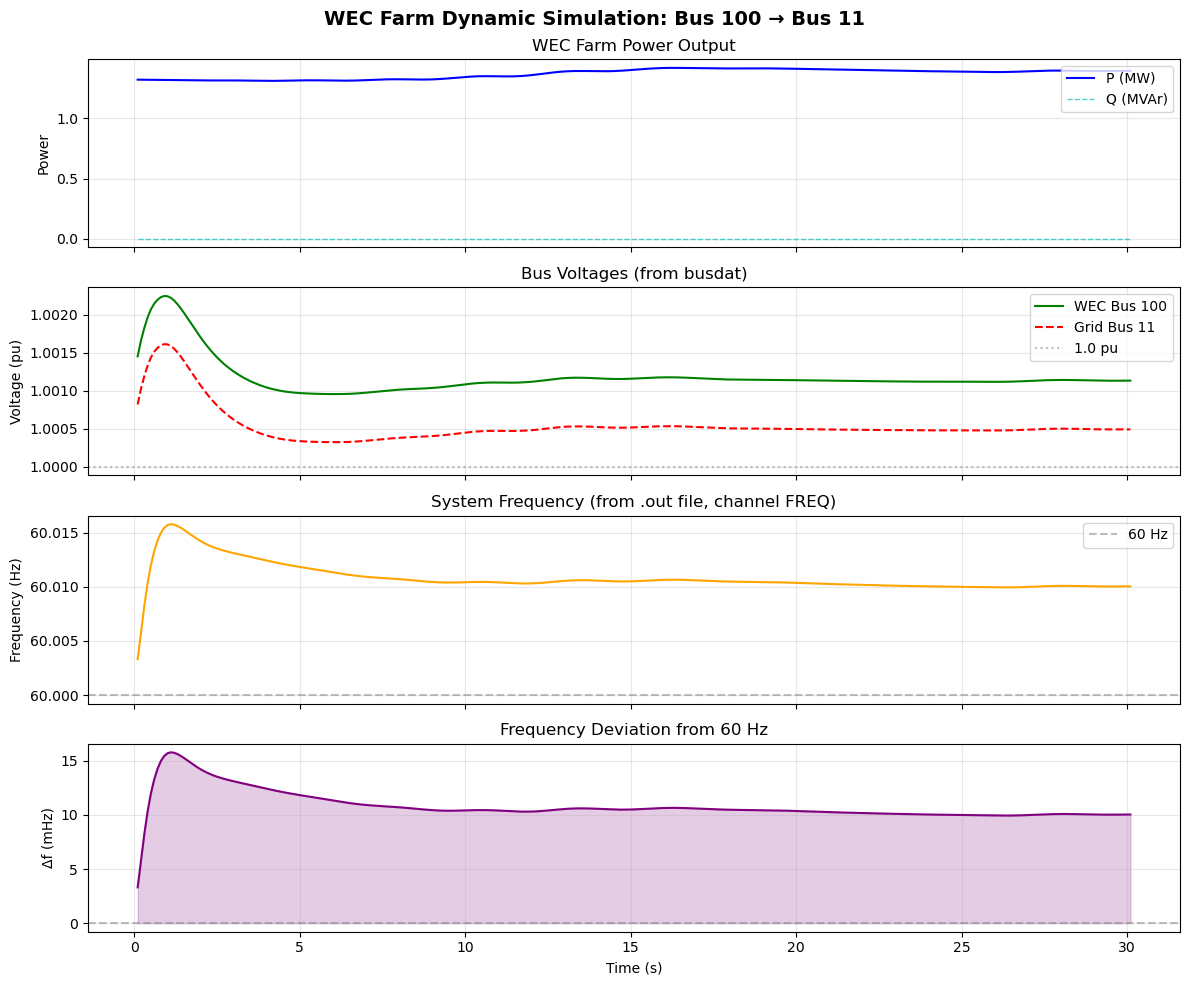


SIMULATION SUMMARY
  WEC Bus:              100 (connected to Bus 11)
  Number of Devices:    100
  Simulation Duration:  30.1 s
  Timestep:             0.1 s
------------------------------------------------------------
  Mean WEC Power:       1.37 MW
  Mean Voltage Diff:    0.64 mpu (WEC - Grid)
  Mean Freq Deviation:  10.83 mHz
  Max Freq Deviation:   15.79 mHz


In [7]:
# =============================================================================
# Part 6: Visualize Results
# =============================================================================

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f'WEC Farm Dynamic Simulation: Bus {WEC_BUS} → Bus {CONNECTING_BUS}', 
             fontsize=14, fontweight='bold')

# -------------------------------------------------------------------------
# Plot 1: WEC Power Injection
# -------------------------------------------------------------------------
ax1 = axes[0]
ax1.plot(results_df['sim_time'], results_df['p_mw'], 'b-', lw=1.5, label='P (MW)')
ax1.plot(results_df['sim_time'], results_df['q_mvar'], 'c--', lw=1, alpha=0.7, label='Q (MVAr)')
ax1.set_ylabel('Power')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)
ax1.set_title('WEC Farm Power Output')

# -------------------------------------------------------------------------
# Plot 2: Bus Voltages
# -------------------------------------------------------------------------
ax2 = axes[1]
ax2.plot(results_df['sim_time'], results_df['v_wec_bus'], 'g-', lw=1.5, 
         label=f'WEC Bus {WEC_BUS}')
ax2.plot(results_df['sim_time'], results_df['v_connecting_bus'], 'r--', lw=1.5, 
         label=f'Grid Bus {CONNECTING_BUS}')
ax2.axhline(1.0, color='gray', linestyle=':', alpha=0.5, label='1.0 pu')
ax2.set_ylabel('Voltage (pu)')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)
ax2.set_title('Bus Voltages (from busdat)')

# -------------------------------------------------------------------------
# Plot 3: System Frequency
# -------------------------------------------------------------------------
ax3 = axes[2]
ax3.plot(results_df['sim_time'], results_df['freq_hz'], 'orange', lw=1.5)
ax3.axhline(60.0, color='gray', linestyle='--', alpha=0.5, label='60 Hz')
ax3.set_ylabel('Frequency (Hz)')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)
ax3.set_title('System Frequency (from .out file, channel FREQ)')

# -------------------------------------------------------------------------
# Plot 4: Frequency Deviation
# -------------------------------------------------------------------------
ax4 = axes[3]
freq_dev_mhz = (results_df['freq_hz'] - 60.0) * 1000
ax4.plot(results_df['sim_time'], freq_dev_mhz, 'purple', lw=1.5)
ax4.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax4.fill_between(results_df['sim_time'], freq_dev_mhz, 0, alpha=0.2, color='purple')
ax4.set_ylabel('Δf (mHz)')
ax4.set_xlabel('Time (s)')
ax4.grid(alpha=0.3)
ax4.set_title('Frequency Deviation from 60 Hz')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# Print Summary
# -------------------------------------------------------------------------
v_diff_mpu = (results_df['v_wec_bus'] - results_df['v_connecting_bus']) * 1000

print("\n" + "=" * 60)
print("SIMULATION SUMMARY")
print("=" * 60)
print(f"  WEC Bus:              {WEC_BUS} (connected to Bus {CONNECTING_BUS})")
print(f"  Number of Devices:    {NUM_WEC_DEVICES}")
print(f"  Simulation Duration:  {results_df['sim_time'].max():.1f} s")
print(f"  Timestep:             {sim_step} s")
print("-" * 60)
print(f"  Mean WEC Power:       {results_df['p_mw'].mean():.2f} MW")
print(f"  Mean Voltage Diff:    {v_diff_mpu.mean():.2f} mpu (WEC - Grid)")
print(f"  Mean Freq Deviation:  {freq_dev_mhz.mean():.2f} mHz")
print(f"  Max Freq Deviation:   {freq_dev_mhz.abs().max():.2f} mHz")
print("=" * 60)

---

## Technical Notes

### Data Sources

| Data | Source | Method |
|------|--------|--------|
| **Voltage (V_pu)** | Real-time | `psspy.busdat(bus, 'PU')` during simulation loop |
| **Frequency (Hz)** | Output file | `dyntools.CHNF().get_data()` - channel type 12 (FREQ) |
| **WEC Power** | Database | `WECGrid.db` → `wec_power_results` table |

### Output File Channels

The `.out` file contains time-series data for configured channels. We configure:

- **Channel type 12 (FREQ)**: Bus frequency deviation in per-unit
- **Channel type 13 (VOLT)**: Bus voltage magnitude in per-unit

Other available channel types include:
- `1` = SPEED (machine speed)
- `2` = ETERM (machine terminal voltage)
- `7` = PELEC (machine electrical power)
- `14` = ANGLE (bus voltage angle)

### Dynamic Conversion Sequence

The PSS/E dynamic conversion must follow this exact sequence:

```
1. CONL (apiopt=1) → Initialize load conversion
2. CONL (apiopt=2) → Convert loads to specified characteristics  
3. CONL (apiopt=3) → Complete load conversion
4. CONG           → Convert generators
5. ORDR           → Order network equations
6. FACT           → Factorize admittance matrix
7. TYSL           → Initialize algebraic solution
8. DYRE_NEW       → Load dynamic models from DYR file
```

**⚠️ Critical**: `CONL` is a multi-step API requiring 3 sequential calls!

### Load Proxy Pattern

```python
# Create load proxy (once, before dynamics)
psspy.load_data_6(WEC_BUS, 'W1', intgar, [0.0]*8)

# Inject power each timestep (during simulation)
psspy.load_chng_5(WEC_BUS, 'W1', [], [-p_mw, -q_mvar, 0, 0, 0, 0])
#                                      ^^^^^  ^^^^^^^
#                                      Negative values = generation
```

---

## Next Steps

1. **Add more output channels**: Machine speeds, angles, power flows
2. **Multiple WEC buses**: Connect WEC farms at different POIs
3. **FMU integration**: Replace database with live FMU co-simulation
4. **Fault analysis**: Study WEC farm response to grid disturbances